# 2D Heat Equation with EvoKAN-WF

- PDE:
  $$
  \partial_t u = \alpha (u_{xx}+u_{yy}) + u(1-u), \qquad \Omega = (-1,1)^2
  $$
- IC:
  $$
  u(x,y,0)=\cos(\pi x)\cos(\pi y)
  $$
- BC:
  $$
  \frac{\partial u}{\partial n}=0
  $$
- Parameter:
  $\alpha = 0.1$
- Formulation:
  weak form


In [1]:
import cupy as cp
import cupyx.scipy.sparse.linalg

## KAN Network

- Architecture:
  `KAN([2, 4, 4, 4, 1])`
- Input:
  $(x,y)$
- Output:
  scalar field $u(x,y,t)$


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) 

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim, bias=False)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [3]:
class FirstRadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) 

class FastKANFirstLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = False,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = FirstRadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [4]:
class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_min: float = -1.,
        grid_max: float = 1.,
        num_grids: int = 8,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ):
        super(KAN, self).__init__()
        self.layers = torch.nn.ModuleList()


        self.layers.append(
                FastKANFirstLayer(
                    input_dim = layers_hidden[0],
                    output_dim = layers_hidden[1],
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=False,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )


        for in_features, out_features in zip(layers_hidden[1:], layers_hidden[2:]):
            self.layers.append(
                FastKANLayer(
                    in_features,
                    out_features,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=use_base_update,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, update_grid=False):
        y = torch.clone(torch.hstack((x1, x2)))
        for layer in self.layers:
            y = layer(y)
        return y

## Data Generation

- Domain:
  $\Omega = (-1,1)^2$
- Initial field:
  $u(x,y,0)=\cos(\pi x)\cos(\pi y)$
- Grid:
  `dense_points = 64`, `sparse_points = 0`
- Output:
  `grid_x`, `X1_init`, `X2_init`, `U_init`


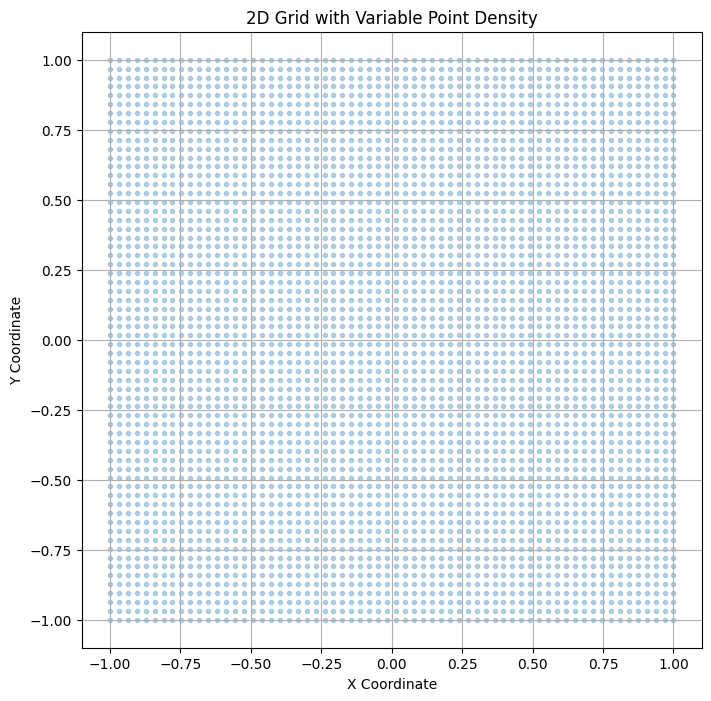

(4096, 2)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_grid(dense_points, sparse_points):
    # Points in the dense region
    dense_segment = np.linspace(-1, 1, dense_points)

    # Points in the sparse regions
    sparse_segment1 = np.linspace(0.01, -0.1, sparse_points, endpoint=False)
    sparse_segment2 = np.linspace(0.1, 1, sparse_points, endpoint=False)

    # Combine segments
    x_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])
    y_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])

    # Create a mesh grid
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    return x_grid.flatten(), y_grid.flatten()

# Set the number of points in each region
dense_points = 64  # More points in the dense interval
sparse_points = 0  # Fewer points in the sparse intervals
num_of_mesh = dense_points + sparse_points

# Generate the grid
x_samples, y_samples = generate_2d_grid(dense_points, sparse_points)

# Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(x_samples, y_samples, alpha=0.3, marker='.')
plt.title('2D Grid with Variable Point Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

grid_x = np.column_stack((x_samples, y_samples))
print(grid_x.shape)

In [6]:
def initial_condition(x1, x2):
  u = np.cos(np.pi * x1) * np.cos(np.pi * x2)
  return u

In [7]:
num_of_x = grid_x.shape[0]
f = initial_condition(grid_x[:, 0], grid_x[:, 1])

print(f.shape)

(4096,)


In [8]:
X1_init = torch.tensor(grid_x[:, 0].reshape(-1,1), requires_grad=True).float()
X2_init = torch.tensor(grid_x[:, 1].reshape(-1,1), requires_grad=True).float()
U_init = torch.tensor(f.reshape(-1,1), requires_grad=True).float()

In [9]:
print(X1_init.shape)
print(X2_init.shape)
print(U_init.shape)

torch.Size([4096, 1])
torch.Size([4096, 1])
torch.Size([4096, 1])


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define model
model = KAN([2, 4, 4, 4, 1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(device)
model.to(device)
# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
# Define loss
criterion = nn.MSELoss()

cpu


In [11]:
# device = torch.device('cpu')
# model  = model.to(device)

In [12]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters:", num_trainable_params)

Number of trainable parameters: 388


In [13]:
def train_step(model:torch.nn.Module,
               X1_init, X2_init, U_init,
               epoch,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device=device):

  train_loss = 0

  # Put model into training mode
  model.train()

  # Put data on target device
  X1_init, X2_init= X1_init.to(device), X2_init.to(device)
  U_init= U_init.to(device)

  # 1. Forward pass
  u_init_pred = model(X1_init, X2_init)

  # 2. Calculate loss and metric
  loss_u_init = loss_fn(u_init_pred, U_init)

  loss = loss_u_init

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Print the loss
  train_loss = loss
  if epoch % 500 ==0:
    print(f"Train loss:{train_loss:.8f}")

In [14]:
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [15]:
torch.manual_seed(42)

# Measure time
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()

# Set epochs
epochs = 30001 # 20001

# Tarin the model
for epoch in tqdm(range(epochs)):
  if epoch % 500 == 0:
    print(f"Epoch:{epoch}\n----------")
  train_step(
      model = model,
      X1_init = X1_init, X2_init = X2_init,  U_init = U_init,
      epoch = epoch,
      loss_fn = criterion,
      optimizer = optimizer,
      device = device
  )

end_time = timer()
total_time = print_train_time(start = start_time, end = end_time, device = device)

  0%|          | 0/30001 [00:00<?, ?it/s]

Epoch:0
----------
Train loss:0.28788400
Epoch:500
----------
Train loss:0.26096344
Epoch:1000
----------
Train loss:0.24655494
Epoch:1500
----------
Train loss:0.22343594
Epoch:2000
----------
Train loss:0.19252008
Epoch:2500
----------
Train loss:0.15927851
Epoch:3000
----------
Train loss:0.12704580
Epoch:3500
----------
Train loss:0.10073631
Epoch:4000
----------
Train loss:0.08133719
Epoch:4500
----------
Train loss:0.06723276
Epoch:5000
----------
Train loss:0.05703206
Epoch:5500
----------
Train loss:0.04971952
Epoch:6000
----------
Train loss:0.04444955
Epoch:6500
----------
Train loss:0.04045728
Epoch:7000
----------
Train loss:0.03704889
Epoch:7500
----------
Train loss:0.03358382
Epoch:8000
----------
Train loss:0.02943952
Epoch:8500
----------
Train loss:0.02462725
Epoch:9000
----------
Train loss:0.01993256
Epoch:9500
----------
Train loss:0.01588684
Epoch:10000
----------
Train loss:0.01260617
Epoch:10500
----------
Train loss:0.01001233
Epoch:11000
----------
Train loss:

## Training Check

- Optimizer:
  `AdamW`, `lr = 1e-5`, `weight_decay = 1e-4`
- Epochs:
  `30001`
- Check:
  initial-condition fit on the full grid


In [16]:
torch.manual_seed(42)
def eval_y(model: torch.nn.Module,
               X1, X2,
               loss_fn: torch.nn.Module,
               device = device):
  loss_res = 0
  model.eval()
  X1, X2 = X1.to(device), X2.to(device)
  y_pred = model(X1, X2)

  return y_pred

In [17]:
u_init_pred = eval_y(model = model,
                     X1 = X1_init, X2 = X2_init,
                     loss_fn = criterion,
                     device = device)

In [18]:
X_plot = np.linspace(0, 1, num_of_mesh)
Y_plot = np.linspace(0, 1, num_of_mesh)

X_plot_mesh, Y_plot_mesh = np.meshgrid(X_plot, Y_plot)

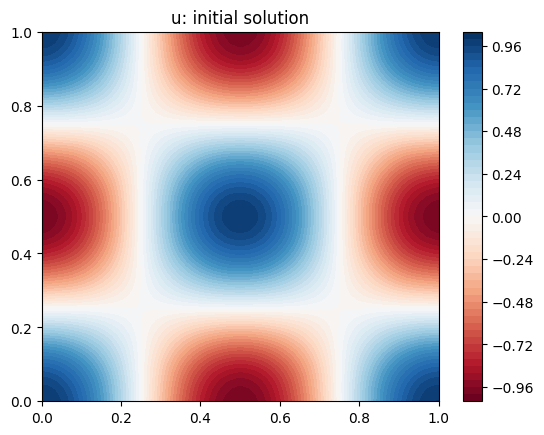

In [19]:
plt.contourf(X_plot_mesh, Y_plot_mesh, u_init_pred.to("cpu").detach().numpy().reshape(num_of_mesh, num_of_mesh), levels=50, cmap='RdBu')
plt.colorbar()
plt.title(f"u: initial solution")
plt.show()

In [20]:
import numpy as np

def calculate_boundary_gradients_mse(u, h):
    n = u.shape[0]  # Assuming u is a square matrix, n should be 101
    
    # Calculate gradients at boundaries using finite differences
    # Left boundary (first column)
    gradient_left = (u[:, 1] - u[:, 0]) / h
    
    # Right boundary (last column)
    gradient_right = (u[:, -1] - u[:, -2]) / h
    
    # Bottom boundary (first row)
    gradient_bottom = (u[1, :] - u[0, :]) / h
    
    # Top boundary (last row)
    gradient_top = (u[-1, :] - u[-2, :]) / h
    
    # Calculate the MSE for each boundary gradient
    mse_left = np.mean(gradient_left**2)
    mse_right = np.mean(gradient_right**2)
    mse_bottom = np.mean(gradient_bottom**2)
    mse_top = np.mean(gradient_top**2)

    return mse_left, mse_right, mse_bottom, mse_top


# Check Neumann boundary conditions
results = calculate_boundary_gradients_mse(u_init_pred.to("cpu").detach().numpy().reshape(num_of_mesh, num_of_mesh), h=2/num_of_mesh)
print("MSE of boundary gradients (Left, Right, Bottom, Top):", results)

MSE of boundary gradients (Left, Right, Bottom, Top): (0.0640499, 0.049915254, 0.06561077, 0.064318754)


## Parameter Derivatives

- Quantity:
  $$
  \frac{\partial u(x_i,y_i)}{\partial w}
  $$
- Tools:
  `functional_call`, `grad`, `vmap`
- Use:
  projected Jacobian construction


In [21]:
from torch.func import functional_call, vmap, grad

def ft_compute_sample_grads(model, X1_init, X2_init):
    params = {k: v.detach() for k, v in model.named_parameters()}
    buffers = {k: v.detach() for k, v in model.named_buffers()}

    def predict(params, buffers, X1_init, X2_init):
        # prepend batch dimension for processing
        X1_init = X1_init.unsqueeze(0)
        X1_init = X1_init.to(device)

        X2_init = X2_init.unsqueeze(0)
        X2_init = X2_init.to(device)

        prediction = functional_call(model, (params, buffers), (X1_init, X2_init))

        return prediction.squeeze()

    ft_compute_grad = grad(predict)
    ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0, 0))
    ft_per_sample_grads = ft_compute_sample_grad(params, buffers, X1_init, X2_init)

    return ft_per_sample_grads

ft_per_sample_grads = ft_compute_sample_grads(model, X1_init, X2_init) # (n_layers, n_samples, out_dim, *)

In [22]:
print(len(ft_per_sample_grads))
print(ft_per_sample_grads.values)

7
<built-in method values of dict object at 0x76f759b52040>


In [23]:
print('num_layers: ', len(ft_per_sample_grads))
print('num_grads per sample: ', sum(g.shape[-2] * g.shape[-1] if len(g.shape) == 3 else g.shape[-1] for _, g in ft_per_sample_grads.items()))
# (n_layers, n_samples, out_dim, in_dim)
print(list(ft_per_sample_grads.values())[1].shape)

num_layers:  7
num_grads per sample:  388
torch.Size([4096, 4, 32])


## Jacobian Assembly

- Matrix:
  $$
  J = \frac{\partial u}{\partial w}
  $$
- Type:
  pointwise Jacobian
- Use:
  weak-form projection


In [24]:
W_origin = list(ft_per_sample_grads.values())
print(len(W_origin))
print(W_origin[0][0].shape)

7
torch.Size([4, 16])


In [25]:
def get_W_flatten(W_origin):
  W_flatten = []
  for i in range(len(W_origin)):
    W_flatten.append(torch.flatten(W_origin[i], start_dim=1))
  W_flatten_matrix = W_flatten[0]
  for i in range(1, len(W_origin)):
    W_flatten_matrix = torch.cat((W_flatten_matrix, W_flatten[i]), 1)
  return W_flatten_matrix

In [26]:
def compute_J():
  ft_per_sample_grads = ft_compute_sample_grads(model, X1_init, X2_init)
  W_origin = list(ft_per_sample_grads.values())
  J = get_W_flatten(W_origin)
  return J

In [27]:
J = compute_J()
print(J.shape)

torch.Size([4096, 388])


## Weak-Form Projection and Quadrature

- Weak form:
  $$
  \int_{\Omega} u_t v_k\, d\Omega
  + \alpha \int_{\Omega} \nabla u \cdot \nabla v_k\, d\Omega
  - \int_{\Omega} u(1-u) v_k\, d\Omega = 0
  $$
- Test basis:
  $v_{p,q}(x,y)=V_p(x)V_q(y)$
- Basis setup:
  `TEST_FUNC_KIND = 'cheb3'`, `Kx = 15`, `Ky = 15`
- Quadrature:
  `Nx = 20`, `Ny = 20`
- Output:
  `X1_q`, `X2_q`, `w2_q`, `V`, `Vx`, `Vy`


In [28]:
# =========================
# DROP-IN: Test functions (Legendre / Chebyshev I–IV)
# - Quadrature nodes/weights: Gauss-Legendre
# - Test functions selected by TEST_FUNC_KIND (legendre|cheb1|cheb2|cheb3|cheb4)
# - Outputs: X1_q, X2_q, w2_q, V, Vx, Vy (keep the existing interface)
# =========================

from numpy.polynomial.legendre import leggauss, legval, legder
import numpy as np
import torch

# ─────────────────────────────────────────────────────────
# 0) Configuration
# TEST_FUNC_KIND = 'cheb3'   # 'legendre' | 'cheb1' | 'cheb2' | 'cheb3' | 'cheb4'
TEST_FUNC_KIND = 'cheb3'   # 'legendre' | 'cheb1' | 'cheb2' | 'cheb3' | 'cheb4'
device = 'cpu'

# ─────────────────────────────────────────────────────────
# 1) Quadrature nodes/weights on [-1,1]^2
Nx, Ny = 40, 40
xi_x, w_x = leggauss(Nx)
xi_y, w_y = leggauss(Ny)

Xx, Yy = np.meshgrid(xi_x, xi_y, indexing="xy")   # [Ny, Nx]
W2      = np.outer(w_y, w_x)                      # [Ny, Nx]

# X1_q, X2_q, w2_q
X1_q = torch.tensor(Xx.reshape(-1,1), requires_grad=True,  device=device).float()  # device=cpu
X2_q = torch.tensor(Yy.reshape(-1,1), requires_grad=True,  device=device).float()
w2_q = torch.tensor(W2.reshape(-1),   requires_grad=False, device=device).float()
Nq    = Nx * Ny

# ─────────────────────────────────────────────────────────
# 2) Build coefficients from Chebyshev initialization and three-term recurrence
def _cheb_init(kind):
    if   kind == 'cheb1': return np.array([1.0]), np.array([1.0,  0.0])  # T0=1,   T1=x
    elif kind == 'cheb2': return np.array([1.0]), np.array([2.0,  0.0])  # U0=1,   U1=2x
    elif kind == 'cheb3': return np.array([1.0]), np.array([2.0,  1.0])  # V0=1,   V1=2x+1
    elif kind == 'cheb4': return np.array([1.0]), np.array([2.0, -1.0])  # W0=1,   W1=2x-1
    else: raise ValueError(kind)

def _cheb_coef(kind, n):
    # P_{n+1} = 2 x P_n - P_{n-1}
    p0, p1 = _cheb_init(kind)
    if n == 0: return p0
    if n == 1: return p1
    a, b = p0, p1
    for _ in range(1, n):
        bshift = np.concatenate([b, [0.0]]) * 2.0
        # Match array lengths
        if bshift.size < a.size: bshift = np.pad(bshift, (a.size - bshift.size, 0))
        if a.size < bshift.size: a = np.pad(a, (bshift.size - a.size, 0))
        a, b = b, (bshift - a)
    return b

def eval_poly_1d(kind, n, x):
    if kind == 'legendre':
        c = np.zeros(n+1); c[n] = 1.0
        return legval(x, c)
    coefs = _cheb_coef(kind, n)
    return np.polyval(coefs, x)

def eval_poly_1d_deriv(kind, n, x):
    if n == 0:
        return np.zeros_like(x)
    if kind == 'legendre':
        c = np.zeros(n+1); c[n] = 1.0
        dc = legder(c)
        return legval(x, dc)
    coefs  = _cheb_coef(kind, n)
    dcoefs = np.polyder(coefs)
    return np.polyval(dcoefs, x)

# ─────────────────────────────────────────────────────────
# 3) 2D test functions v_{p,q}(x,y) = P_p(x) P_q(y)
#    d/dx v_{p,q} = P'_p(x) P_q(y),  d/dy v_{p,q} = P_p(x) P'_q(y)
Kx, Ky = 15, 15  # total K = Kx*Ky

# 1D basis values/derivatives (vectorized)
Px  = np.stack([eval_poly_1d(       TEST_FUNC_KIND, p, xi_x) for p in range(Kx)], axis=0)  # [Kx, Nx]
dPx = np.stack([eval_poly_1d_deriv( TEST_FUNC_KIND, p, xi_x) for p in range(Kx)], axis=0)  # [Kx, Nx]
Py  = np.stack([eval_poly_1d(       TEST_FUNC_KIND, q, xi_y) for q in range(Ky)], axis=0)  # [Ky, Ny]
dPy = np.stack([eval_poly_1d_deriv( TEST_FUNC_KIND, q, xi_y) for q in range(Ky)], axis=0)  # [Ky, Ny]

def kron2(Ay, Ax):  # Ay:[Ky,Ny], Ax:[Kx,Nx] -> [Ky*Kx, Ny*Nx]
    return np.kron(Ay, Ax)

V_np  = kron2(Py,  Px )   # v(x,y)
Vx_np = kron2(Py,  dPx)   # ∂v/∂x
Vy_np = kron2(dPy, Px )   # ∂v/∂y

# V, Vx, Vy
V  = torch.tensor(V_np,  dtype=torch.float32, device=device)
Vx = torch.tensor(Vx_np, dtype=torch.float32, device=device)
Vy = torch.tensor(Vy_np, dtype=torch.float32, device=device)

# sanity check
K = Kx * Ky
assert V.shape  == (K, Nq)
assert Vx.shape == (K, Nq)
assert Vy.shape == (K, Nq)


In [29]:
# 3) Function to evaluate the strong-form J at quadrature points (2D)
def compute_J_strong_2d(X1_pts: torch.Tensor, X2_pts: torch.Tensor):
    """
    X1_pts, X2_pts: Tensor[Nq, 1]  (CPU recommended)
    returns       : J_strong (Tensor[Nq, P], CPU, float32)
    """
    # --- Keep CPU consistency ---
    device_cpu = torch.device('cpu')
    # Force the model and inputs onto CPU
    _ = model.to(device_cpu)
    X1_cpu = X1_pts.detach().to(device_cpu)
    X2_cpu = X2_pts.detach().to(device_cpu)

    # Compute ∂u/∂w at each quadrature point
    ft_per_sample_grads = ft_compute_sample_grads(model, X1_cpu, X2_cpu)
    W_origin            = list(ft_per_sample_grads.values())
    J                   = get_W_flatten(W_origin)   # [Nq, P]

    # NumPy -> Torch conversion and dtype cleanup (stay on CPU)
    if isinstance(J, np.ndarray):
        J = torch.from_numpy(J)
    return J.to(device_cpu).float()  # CPU, float32

# 4) Function to compute the weak-form J (2D)
def compute_J_weak_2d(J_strong: torch.Tensor, V: torch.Tensor, w2: torch.Tensor):
    """
    J_strong: [Nq, P] (CPU),  V: [K, Nq] (CPU),  w2: [Nq] (CPU)
    returns   : J_weak = V * diag(w2) * J_strong  -> [K, P] (CPU, float32)
    """
    device_cpu = torch.device('cpu')

    # --- CPU consistency + dtype cleanup ---
    J_strong = J_strong.to(device_cpu).float()
    V        = V.to(device_cpu).float()
    w2       = w2.to(device_cpu).float()

    # Apply quadrature weights
    J_weighted = w2[:, None] * J_strong      # [Nq, P]
    J_weak     = V.matmul(J_weighted)        # [K,  P]
    return J_weak  # CPU, float32

# 5) Actual call (CPU-consistent)
J_strong_quad = compute_J_strong_2d(X1_q, X2_q)       # [Nq, P], CPU
J_weak        = compute_J_weak_2d(J_strong_quad, V, w2_q)  # [K, P], CPU
print(J_weak.shape)


torch.Size([225, 388])


In [30]:
def change_to_np(list_vars):
  numpy_vars = []
  for i in range(len(list_vars)):
    numpy_vars.append(list_vars[i].cpu().detach().numpy())

  return numpy_vars

In [31]:
def store_parameter_size(list_vars):
  iter = len(list_vars)
  mat_size = []
  vec_size = []
  for i in range(iter):
    temp_vec = np.ndarray.flatten(list_vars[i], order='C')
    mat_size.append(list_vars[i].shape)
    vec_size.append(temp_vec.shape)
  return mat_size, vec_size

In [32]:
trainable_params = [param for param in model.parameters() if param.requires_grad]
np_vars = change_to_np(list(trainable_params))
mat_size, vec_size = store_parameter_size(np_vars)
print(mat_size)
print(vec_size)

[(4, 16), (4, 32), (4, 4), (4, 32), (4, 4), (1, 32), (1, 4)]
[(64,), (128,), (16,), (128,), (16,), (32,), (4,)]


In [33]:
def unfold_parameters(list_vars):
  mat_size, vec_size = store_parameter_size(list_vars)

  total_len = 0
  for i in range(len(vec_size)):
    total_len = total_len + vec_size[i][0]

  flat_vec = np.zeros(shape=(total_len,))
  iter = len(list_vars)
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    flat_vec[index:end_index] = np.ndarray.flatten(list_vars[i], order='C')
    index = index + vec_size[i][0]

  return flat_vec

In [34]:
def fold_vectors(vector, mat_size = mat_size, vec_size = vec_size):
  iter = len(mat_size)
  output_list = []
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    temp_mat = vector[index:end_index]
    output_list.append(np.reshape(temp_mat, mat_size[i], order='C'))
    index = index + vec_size[i][0]

  return output_list

In [35]:
flat_vec = unfold_parameters(np_vars)
print(len(flat_vec))
reconstruct_mat = fold_vectors(flat_vec, mat_size, vec_size)
print(len(reconstruct_mat))
print(reconstruct_mat[2].shape)

388
7
(4, 4)


## Spatial Derivatives

- Compute:
  $u$, $u_x$, $u_{xx}$, $u_y$, $u_{yy}$
- Method:
  autograd on quadrature points
- Use:
  projected diffusion and diagnostics


In [36]:
torch.manual_seed(42)
def Compute_gradient(model: torch.nn.Module,
                       X1, X2,
                       device = device):
  loss_res = 0
  model.eval()
  X1, X2 = X1.to(device), X2.to(device)

  # 1. Forward pass
  u_pred = model(X1, X2)

  # 2. Calculate loss and metric

  u_x = torch.autograd.grad(
      u_pred, X1,
      grad_outputs = torch.ones_like(u_pred),
      retain_graph = True,
      create_graph = True)[0]

  u_xx = torch.autograd.grad(
      u_x, X1,
      grad_outputs = torch.ones_like(u_x),
      retain_graph = True,
      create_graph = True)[0]

  u_y = torch.autograd.grad(
      u_pred, X2,
      grad_outputs = torch.ones_like(u_pred),
      retain_graph = True,
      create_graph = True)[0]

  u_yy = torch.autograd.grad(
      u_y, X2,
      grad_outputs = torch.ones_like(u_y),
      retain_graph = True,
      create_graph = True)[0]

  return u_pred, u_x, u_xx, u_y, u_yy

In [37]:
u, u_x, u_xx, u_y, u_yy = Compute_gradient(model, X1_init, X2_init)
u, u_x, u_xx, u_y, u_yy = u.to("cpu").detach().numpy(), u_x.to("cpu").detach().numpy(), u_xx.to("cpu").detach().numpy(), u_y.to("cpu").detach().numpy(), u_yy.to("cpu").detach().numpy()

## Compute $N$ and $E$

- Operator:
  $$
  N(u)=\alpha (u_{xx}+u_{yy}) + u(1-u)
  $$
- Constants:
  `vis = 0.1`, `lamb = 1`
- Use:
  diagnostics and stabilization terms


In [38]:
def compute_N(u, u_x, u_y, u_xx, u_yy):
  vis = 0.1
  lamb = 1
  N = vis * (u_xx + u_yy) + lamb * u * (1 - u)
  return N

## Weak-Form Right-Hand Side

- Vector:
  $$
  b_{\mathrm{weak}}
  = -\eta \left[
  \alpha \int_{\Omega} \nabla u \cdot \nabla v_k\, d\Omega
  - \int_{\Omega} u(1-u)\, v_k\, d\Omega
  \right]
  $$
- Terms:
  diffusion + reaction
- Inputs:
  `V`, `Vx`, `Vy`, `w2`, `u`, `u_x`, `u_y`


In [39]:
# 2D: Build the weak-form nonlinear reaction-diffusion RHS (with IBP)
# Required objects: X1_q, X2_q, V, Vx, Vy, w2 (from the 2D quadrature/basis block)
# Assume Compute_gradient(model, X1_q, X2_q) -> u, u_x, u_xx, u_y, u_yy is already defined

def compute_b_weak_2d(X1_q: torch.Tensor,
                      X2_q: torch.Tensor,
                      V:  torch.Tensor,   # [K, Nq]
                      Vx: torch.Tensor,   # [K, Nq]
                      Vy: torch.Tensor,   # [K, Nq]
                      w2: torch.Tensor,   # [Nq]
                      eta: float = 1.0,
                      vis: float = 0.1,   # ν
                      lamb: float = 1.0   # λ
                      ) -> torch.Tensor:
    """
    returns: b_weak in R^K
      b = -η [ ν∫Ω ∇u·∇v dΩ - λ∫Ω u(1-u) v dΩ ]
        ≈ -η [ Vx @ (w ⊙ (ν u_x)) + Vy @ (w ⊙ (ν u_y))  -  V @ (w ⊙ (λ u(1-u))) ]
    """
    device = V.device
    X1_q, X2_q = X1_q.to(device), X2_q.to(device)
    V, Vx, Vy, w2 = V.to(device), Vx.to(device), Vy.to(device), w2.to(device)

    # Model derivatives
    u, u_x, u_xx, u_y, u_yy = Compute_gradient(model, X1_q, X2_q)  # each [Nq, 1]
    uu = u.squeeze(-1)
    ux = u_x.squeeze(-1)
    uy = u_y.squeeze(-1)

    # Diffusion term: ∫ nu grad(u)·grad(v)
    diff_term  = Vx.matmul(w2 * (vis * ux)) + Vy.matmul(w2 * (vis * uy))   # [K]
    # Reaction term: ∫ lambda u(1-u) v
    react_term = V.matmul(w2 * (lamb * uu * (1.0 - uu)))                   # [K]

    return -eta * (diff_term - react_term)  # [K]


In [40]:
import numpy as np

def compute_boundary_derivatives_directly(J, h=2/(num_of_mesh)):
    n = num_of_mesh  # Number of points along each dimension

    # Calculate indices for boundaries
    left_indices = np.arange(0, n**2, n)
    right_indices = np.arange(n-1, n**2, n)
    bottom_indices = np.arange(0, n)
    top_indices = np.arange(n*(n-1), n**2)

    # Compute derivatives
    # u_x at x = -1 (left boundary)
    ux_left = (J[left_indices + 1] - J[left_indices]) / h

    # u_x at x = 1 (right boundary)
    ux_right = (J[right_indices] - J[right_indices - 1]) / h

    # u_y at y = -1 (bottom boundary)
    uy_bottom = (J[bottom_indices + n] - J[bottom_indices]) / h

    # u_y at y = 1 (top boundary)
    uy_top = (J[top_indices] - J[top_indices - n]) / h

    bc_left = np.vstack((ux_left, ux_right, uy_bottom, uy_top))

    return bc_left

In [41]:
def compute_N_bc(bc_left):
  N_1 = np.zeros(shape=(bc_left.shape[0] ,1))
  return N_1

In [42]:
def compute_E(u, u_x, u_y):
  E = 0.5*(u_x**2 + u_y**2)
  return E

In [43]:
def compute_r(energy, M, delta_t, previous_r):
  r = previous_r / (1 + delta_t*M/(2*energy))
  return r

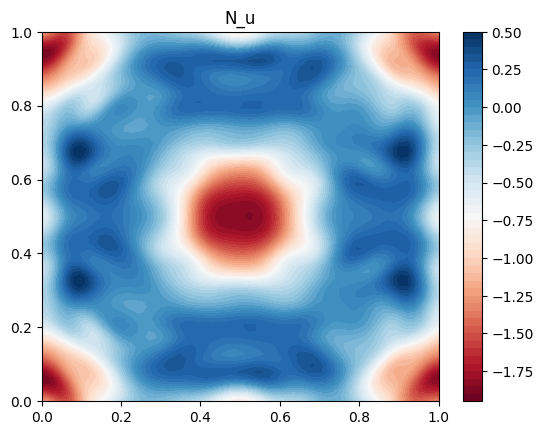

In [44]:
N = compute_N(u, u_x, u_y, u_xx, u_yy)

plt.contourf(X_plot, Y_plot, N.reshape(num_of_mesh, num_of_mesh), levels=50, cmap='RdBu')
plt.colorbar()
plt.title(f"N_u")
plt.show()

## Assign Parameters Back to the Model

- Input:
  unfolded parameter update
- Steps:
  `fold_vectors(...)` -> `update_weights(...)`
- Purpose:
  restore model tensors


In [45]:
def update_weights(new_vars):
  weights_tensor = []
  for i in range(len(new_vars)):
    weights_tensor.append(torch.tensor(new_vars[i]).float())

  trainable_params = [(name, param) for name, param in model.named_parameters() if param.requires_grad]
  for i, (name, param_tensor) in enumerate(trainable_params):
    model.state_dict()[name][:] = weights_tensor[i]

  '''
  for i, param_tensor in enumerate(model.state_dict()):
    model.state_dict()[param_tensor][:] = weights_tensor[i]
  '''

  return None

## Main Step

- Assemble:
  $J_{\mathrm{weak}}$ and $b_{\mathrm{weak}}$
- Solve:
  `scipy.sparse.linalg.lsmr`
- Marching:
  `delta_t = 1e-3`, `steps = 500`
- Return:
  updated weights, energy, BC errors, iteration counts


In [46]:
import cupy as cp
import cupyx.scipy.sparse.linalg
import scipy
import numpy as np
import time as _time


def one_step_ahead(t_start, delta_t, previous_r, step_idx):
  # Compute w
  trainable_params = [param for param in model.parameters() if param.requires_grad]
  np_model_vars = change_to_np(list(trainable_params))
  mat_size, vec_size = store_parameter_size(np_model_vars)
  w = unfold_parameters(np_model_vars)

  # ==== Existing strong-form block kept for reference; weak form is used below ====
  # # Compute J (strong)
  # J = compute_J()
  # J = J.to("cpu").detach().numpy().astype("float64")

  # # Compute N (strong)
  u, u_x, u_xx, u_y, u_yy = Compute_gradient(model, X1_init, X2_init)
  u, u_x, u_xx, u_y, u_yy = (
      u.to("cpu").detach().numpy(),
      u_x.to("cpu").detach().numpy(),
      u_xx.to("cpu").detach().numpy(),
      u_y.to("cpu").detach().numpy(),
      u_yy.to("cpu").detach().numpy()
  )

  # Boundary-gradient storage (keep this block)
  mse_l, mse_r, mse_b, mse_t = calculate_boundary_gradients_mse(
      u.reshape(num_of_mesh, num_of_mesh), h=2/num_of_mesh
  )

  # ==== Assemble the weak-form least-squares system ====
  # 1) A_t = J_weak = V * diag(w2_q) * J_strong
  J_strong_quad = compute_J_strong_2d(X1_q, X2_q)             # [Nq, P] (Tensor)
  J_weak        = compute_J_weak_2d(J_strong_quad, V, w2_q)    # [K, P] (Tensor)
  A_np = J_weak.detach().cpu().numpy().astype("float64")

  # 2) b_weak = -eta * [ α∫∇u·∇v - ∫u(1-u)v ]
  b_weak = compute_b_weak_2d(
      X1_q, X2_q, V, Vx, Vy, w2_q,
      eta=1.0, vis=0.1, lamb=1.0
  )  # [K] (Tensor)
  right_side = b_weak.detach().cpu().numpy().astype("float64")

  # ==== Scaling and energy evaluation: keep the original logic as much as possible ====
  E = compute_E(u, u_x, u_y)
  energy = float(np.sum(E) / len(E))

  # M used to be computed from N; it is now computed from b_weak
  M = float(np.mean(right_side**2))
  new_r = compute_r(energy, M, delta_t, previous_r)
  new_eta = new_r / max(np.sqrt(energy), 1e-12)

  # ==== Solve dw/dt with LSMR ====
  # When using the GPU version:
  # A_gpu = cp.asarray(A_np)
  # rhs_gpu = cp.asarray(right_side)
  # dw_dt = cupyx.scipy.sparse.linalg.lsmr(A_gpu, rhs_gpu, maxiter=lsmr_maxiter)[0].get()
  lsmr_result = scipy.sparse.linalg.lsmr(A_np, right_side)
  
  dw_dt = lsmr_result[0]
  lsmr_itn = int(lsmr_result[2])

  # Compute new w
  new_w = w + delta_t * dw_dt
  new_vars = fold_vectors(new_w)

  # Update model parameters
  update_weights(new_vars)

  return new_w, new_r, new_eta, energy, mse_l, mse_r, mse_b, mse_t, lsmr_itn


In [47]:
E_0 = compute_E(u, u_x, u_y)
energy_0 = np.sum(E_0)/len(E_0)
r_0 = np.sqrt(energy_0)
print(r_0)

1.5710224425657215


In [48]:
t_start = 0.0
delta_t = 1e-3
steps   = 500

r_list          = [r_0]     # r_0 must be defined beforehand
energy_hist     = []
time            = []
coefficient_list = []
lsmr_iterations = []

mse_left = []; mse_right = []; mse_bottom = []; mse_top = []
# wall clock time
loop_start = _time.perf_counter()

for i in range(steps):
    if i % 10 == 0:
        print(i)

    new_w, new_r, new_eta, new_energy, mse_l, mse_r, mse_b, mse_t, lsmr_itn = one_step_ahead(
        t_start, delta_t, r_list[i], step_idx=i
    )

    # Stabilize eta using new_energy from the current step
    if (new_eta < 0.98) or (new_eta > 1.02):
        new_r = np.sqrt(max(new_energy, 0.0))

    # Update time and log quantities
    t_start += delta_t
    time.append(t_start)
    r_list.append(new_r)
    coefficient_list.append(new_w)
    energy_hist.append(new_energy)
    lsmr_iterations.append(lsmr_itn)

    mse_left.append(mse_l); mse_right.append(mse_r)
    mse_bottom.append(mse_b); mse_top.append(mse_t)
final_t = t_start
loop_end = _time.perf_counter()

print(final_t)
print(f"Total wall clock time (loop): {loop_end - loop_start:.6f} s")
print("LSMR iteration samples:", lsmr_iterations[:10])

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
0.5000000000000003
Total wall clock time (loop): 49.193642 s
LSMR iteration samples: [225, 225, 225, 225, 225, 225, 225, 225, 225, 225]


In [49]:
test_u, test_u_x, test_u_xx, test_u_y, test_u_yy = Compute_gradient(model, X1_init, X2_init)

In [50]:
velocity_u = test_u.to("cpu").detach().numpy()

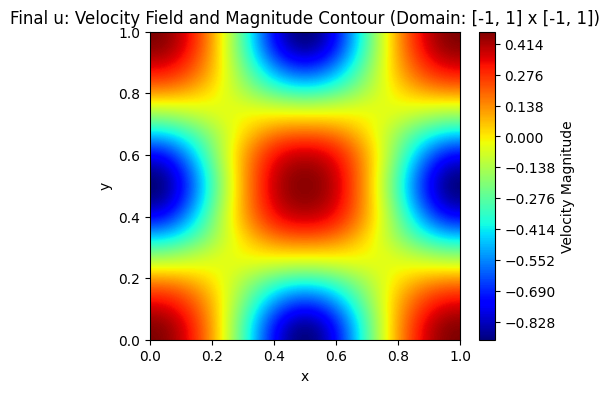

In [51]:
# Plotting the combined contour and quiver plot for the new domain
plt.figure(figsize=(5, 4))

# Contour plot of the velocity magnitude
plt.contourf(X_plot_mesh, Y_plot_mesh, velocity_u.reshape(num_of_mesh, num_of_mesh), levels=500, cmap='jet')
plt.colorbar(label='Velocity Magnitude')

# Titles and labels
plt.title('Final u: Velocity Field and Magnitude Contour (Domain: [-1, 1] x [-1, 1])')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

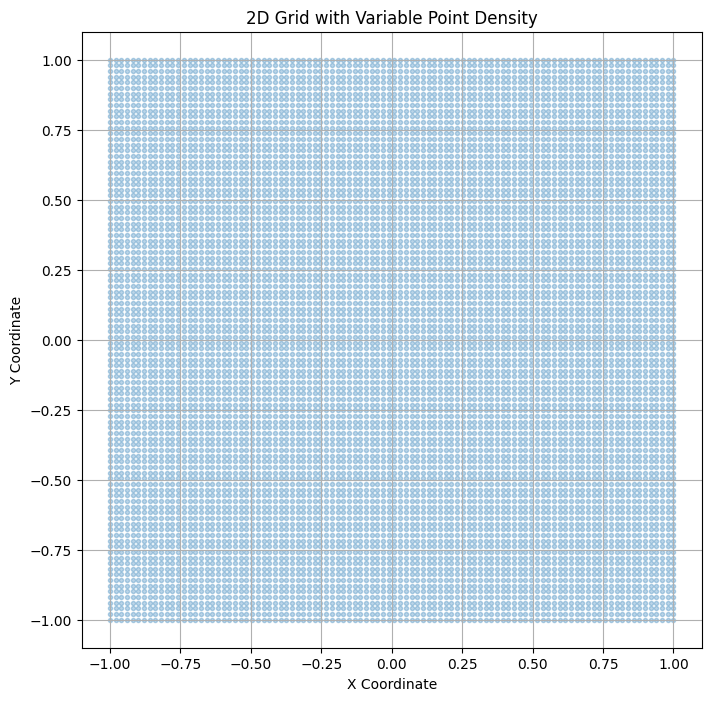

(10000, 2)


In [52]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_grid(dense_points, sparse_points):
    # Points in the dense region
    dense_segment = np.linspace(-1, 1, dense_points)

    # Points in the sparse regions
    sparse_segment1 = np.linspace(0.01, -0.1, sparse_points, endpoint=False)
    sparse_segment2 = np.linspace(0.1, 1, sparse_points, endpoint=False)

    # Combine segments
    x_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])
    y_values = np.concatenate([sparse_segment1, dense_segment, sparse_segment2])

    # Create a mesh grid
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    return x_grid.flatten(), y_grid.flatten()

# Set the number of points in each region
dense_points = 100  # More points in the dense interval
sparse_points = 0  # Fewer points in the sparse intervals
num_of_mesh = dense_points + sparse_points

# Generate the grid
x_samples, y_samples = generate_2d_grid(dense_points, sparse_points)

# Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(x_samples, y_samples, alpha=0.3, marker='.')
plt.title('2D Grid with Variable Point Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

grid_x = np.column_stack((x_samples, y_samples))
print(grid_x.shape)

X1_init = torch.tensor(grid_x[:, 0].reshape(-1,1), requires_grad=True).float()
X2_init = torch.tensor(grid_x[:, 1].reshape(-1,1), requires_grad=True).float()

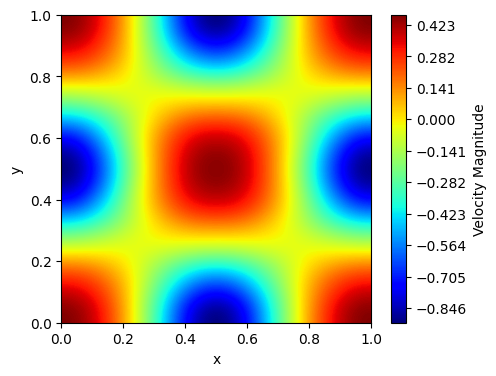

In [53]:
test_u, test_u_x, test_u_xx, test_u_y, test_u_yy = Compute_gradient(model, X1_init, X2_init)
velocity_u = test_u.to("cpu").detach().numpy()
# Plotting the combined contour and quiver plot for the new domain
plt.figure(figsize=(5, 4))

X_plot = np.linspace(0, 1, num_of_mesh)
Y_plot = np.linspace(0, 1, num_of_mesh)

X_plot_mesh, Y_plot_mesh = np.meshgrid(X_plot, Y_plot)

# Contour plot of the velocity magnitude
plt.contourf(X_plot_mesh, Y_plot_mesh, velocity_u.reshape(num_of_mesh, num_of_mesh), levels=500, cmap='jet')
plt.colorbar(label='Velocity Magnitude')

# Titles and labels
# plt.title('Final u: Velocity Field and Magnitude Contour (Domain: [-1, 1] x [-1, 1])')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [54]:
import os
import numpy as np
import torch

# 1) Create the output directory
save_dir = "2D_Heat_EvoKAN_WF_April03_2026"
os.makedirs(save_dir, exist_ok=True)

# 2) Select output times (0.0, 0.1, ..., 0.7)
# time_targets = np.arange(0.0, 0.75, 0.01)
time_targets = np.arange(0.0, 0.50 + 1e-8, 0.01)
time_array = np.array(time)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]

# 3) Flatten the coordinates used by Compute_gradient
x1_flat = X1_init.flatten()
x2_flat = X2_init.flatten()

# Domain boundary values computed after NumPy conversion
x1_np = x1_flat.detach().cpu().numpy()
x2_np = x2_flat.detach().cpu().numpy()
xmin, xmax = x1_np.min(), x1_np.max()
ymin, ymax = x2_np.min(), x2_np.max()

# 4) Accumulate boundary-gradient results
boundary_grads = []

for T, idx in zip(time_targets, indices_to_update):
    # 4.1) Update model parameters
    update_weights(fold_vectors(coefficient_list[idx]))
    
    # 4.2) Evaluate the PINN solution and gradients (torch.Tensor)
    test_u, test_u_x, _, test_u_y, _ = Compute_gradient(model, X1_init, X2_init)
    
    # 4.3) Convert GPU tensors to NumPy arrays and flatten
    u_np  = test_u .detach().cpu().numpy().flatten()
    ux_np = test_u_x.detach().cpu().numpy().flatten()
    uy_np = test_u_y.detach().cpu().numpy().flatten()
    
    # 4.4) Save the (x, y, u) three-column data
    sol_data = np.column_stack([x1_np, x2_np, u_np])
    sol_fname = os.path.join(save_dir, f"solution_t_{T:.2f}.txt")
    np.savetxt(
        sol_fname,
        sol_data,
        header="x y u",
        comments="",
        fmt="%.6f"
    )
    
    # 4.5) Compute boundary masks and mean gradients (NumPy side)
    mask_left  = np.isclose(x1_np, xmin)
    mask_right = np.isclose(x1_np, xmax)
    mask_lower = np.isclose(x2_np, ymin)
    mask_upper = np.isclose(x2_np, ymax)

    grad_left_mean   = ux_np[mask_left ].mean()
    grad_right_mean  = ux_np[mask_right].mean()
    grad_lower_mean  = uy_np[mask_lower].mean()
    grad_upper_mean  = uy_np[mask_upper].mean()
    
    boundary_grads.append([
        T,
        grad_left_mean,
        grad_right_mean,
        grad_upper_mean,
        grad_lower_mean,
    ])
    print(f"[t={T:.2f}] solution & grads saved")
    
# 5) Save the full boundary-gradient table
boundary_grads = np.array(boundary_grads)
grad_fname = os.path.join(save_dir, "2D_Heat_EvoKAN_WF_gradient.txt")
np.savetxt(
    grad_fname,
    boundary_grads,
    header="t grad_left grad_right grad_upper grad_lower",
    comments="",
    fmt="%.6f"
)
print(f"[Done] Saved to '{grad_fname}'.")


[t=0.00] solution & grads saved
[t=0.01] solution & grads saved
[t=0.02] solution & grads saved
[t=0.03] solution & grads saved
[t=0.04] solution & grads saved
[t=0.05] solution & grads saved
[t=0.06] solution & grads saved
[t=0.07] solution & grads saved
[t=0.08] solution & grads saved
[t=0.09] solution & grads saved
[t=0.10] solution & grads saved
[t=0.11] solution & grads saved
[t=0.12] solution & grads saved
[t=0.13] solution & grads saved
[t=0.14] solution & grads saved
[t=0.15] solution & grads saved
[t=0.16] solution & grads saved
[t=0.17] solution & grads saved
[t=0.18] solution & grads saved
[t=0.19] solution & grads saved
[t=0.20] solution & grads saved
[t=0.21] solution & grads saved
[t=0.22] solution & grads saved
[t=0.23] solution & grads saved
[t=0.24] solution & grads saved
[t=0.25] solution & grads saved
[t=0.26] solution & grads saved
[t=0.27] solution & grads saved
[t=0.28] solution & grads saved
[t=0.29] solution & grads saved
[t=0.30] solution & grads saved
[t=0.31]